# TCN Model — Predicting the Next Sensor Reading to Catch Early Degradation

**Author:** Emmy
**Dataset:** NASA C-MAPSS Turbofan Engine Degradation Simulation (FD001 subset)
**Goal of this notebook:** build a **TCN (Temporal Convolutional Network)** that learns what a
*healthy* engine's next sensor reading should look like, given its recent history. Once trained, we
use how *wrong* its predictions are as a warning signal: if the model is regularly surprised by what
it sees, that's a sign the engine's behaviour has started to change.

This is the "Blew the model up?" idea from the project brief: the TCN guesses the next reading from
the last 30 cycles. When it guesses wrong a lot, the engine's behaviour has drifted away from what its
own history predicted — an early sign of degradation.

This notebook picks up exactly where `emmy_analysis.ipynb` left off, and uses the same decisions we
already justified there with real numbers.

Every chart in this notebook saves itself automatically into `reports/figures/`, continuing the same
naming convention as `emmy_analysis.ipynb` (`{number}.emmy_{description}.png`, numbered in the order
they're created — this notebook picks up at 9, since the analysis notebook already used 1-8).


## Recap: decisions carried over from the analysis notebook

- **Dataset:** FD001 only (`train_FD001.txt`, `test_FD001.txt`, `RUL_FD001.txt`) — one operating
  condition, one fault mode.
- **Sensors:** drop the 7 near-constant ones (`sensor_1, sensor_5, sensor_6, sensor_10, sensor_16,
  sensor_18, sensor_19`), keep the other **14**.
- **Healthy period:** the first **30%** of each engine's life.
- **Window size:** **30 cycles** of history per prediction.
- **Scaling:** every sensor gets rescaled, fit only on healthy training data.

Re-deriving these here (instead of hardcoding the numbers) keeps this notebook self-contained and
double-checks that nothing changed.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", 30)


## 1. Load the data and recreate the sensor selection


In [2]:
index_names = ["unit_number", "time_in_cycles"]
setting_names = ["op_setting_1", "op_setting_2", "op_setting_3"]
sensor_names = [f"sensor_{i}" for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

DATA_DIR = "../data/raw"

train = pd.read_csv(f"{DATA_DIR}/train_FD001.txt", sep=r"\s+", header=None, names=col_names)
test = pd.read_csv(f"{DATA_DIR}/test_FD001.txt", sep=r"\s+", header=None, names=col_names)
rul_test = pd.read_csv(f"{DATA_DIR}/RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"])

# Same "how many different values does each sensor take" check as the analysis notebook
n_unique = train[sensor_names].nunique()
drop_sensors = n_unique[n_unique <= 2].index.tolist()
keep_sensors = [s for s in sensor_names if s not in drop_sensors]

print(f"Dropping {len(drop_sensors)} near-constant sensors: {drop_sensors}")
print(f"Keeping {len(keep_sensors)} sensors for the model")


Dropping 7 near-constant sensors: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Keeping 14 sensors for the model


## 2. Mark each row as "healthy" or not

Same rule as before: the first 30% of an engine's life counts as healthy. We'll train the TCN
*only* on healthy data, so it learns what normal behaviour looks like.


In [3]:
cycles_per_engine = train.groupby("unit_number")["time_in_cycles"].max()

train = train.merge(cycles_per_engine.rename("life"), on="unit_number")
train["life_fraction"] = train["time_in_cycles"] / train["life"]
train["is_healthy"] = train["life_fraction"] <= 0.30

print(f"Healthy rows: {train['is_healthy'].sum()} / {len(train)} "
      f"({train['is_healthy'].mean():.0%})")


Healthy rows: 6144 / 20631 (30%)


## 3. Scale the sensors

The analysis notebook showed sensor ranges vary from single digits to several thousand. We fit the
scaler **only on healthy training rows**, then apply it everywhere — this way the model never
"peeks" at degraded behaviour while learning what normal looks like, and the test set is scaled the
exact same way as training.

We use min-max scaling here (squashes every sensor into roughly the 0-1 range), which is a common
choice for neural networks like the TCN. Because the scaler only ever saw *healthy* readings, healthy
rows will land close to 0-1 — but degrading rows can end up slightly outside that range. That's not a
bug: it's actually useful, since it means "outside the range the model was calibrated on" is itself a
small hint of degradation.


In [4]:
scaler = MinMaxScaler()
scaler.fit(train.loc[train["is_healthy"], keep_sensors])

print("Example ranges BEFORE scaling:")
print(train[keep_sensors].agg(["min", "max"]).T.head(3))

train[keep_sensors] = scaler.transform(train[keep_sensors])
test[keep_sensors] = scaler.transform(test[keep_sensors])

print()
print("Example ranges AFTER scaling, healthy rows only (should sit close to 0-1):")
print(train.loc[train["is_healthy"], keep_sensors].agg(["min", "max"]).T.head(3))

print()
print("Example ranges AFTER scaling, ALL rows including degrading ones:")
print(train[keep_sensors].agg(["min", "max"]).T.head(3))


Example ranges BEFORE scaling:
              min      max
sensor_2   641.21   644.53
sensor_3  1571.04  1616.91
sensor_4  1382.25  1441.49

Example ranges AFTER scaling, healthy rows only (should sit close to 0-1):
          min  max
sensor_2  0.0  1.0
sensor_3  0.0  1.0
sensor_4  0.0  1.0

Example ranges AFTER scaling, ALL rows including degrading ones:
          min       max
sensor_2  0.0  1.281853
sensor_3  0.0  1.376651
sensor_4  0.0  1.454813


## 4. Turn each engine's history into 30-cycle windows

The TCN's job is: *given the last 30 readings, guess the next one.* So for every engine, we slide a
30-cycle window along its healthy period and pair each window with the reading that comes right
after it — that's one training example.

Windows never cross between engines (each engine's history is its own sequence), and for training we
only use windows built from **healthy** cycles.


In [5]:
WINDOW = 30

def make_windows(arr, window=WINDOW):
    """Turn a (time, features) array into sliding-window inputs X and next-step targets y."""
    X, y = [], []
    for t in range(window, len(arr)):
        X.append(arr[t - window:t])
        y.append(arr[t])
    return np.array(X), np.array(y)

X_train_parts, y_train_parts = [], []
for unit in train["unit_number"].unique():
    engine = train[train["unit_number"] == unit].sort_values("time_in_cycles")
    healthy = engine[engine["is_healthy"]]
    X_unit, y_unit = make_windows(healthy[keep_sensors].values)
    if len(X_unit) > 0:
        X_train_parts.append(X_unit)
        y_train_parts.append(y_unit)

X_train = np.concatenate(X_train_parts)
y_train = np.concatenate(y_train_parts)

print(f"X_train shape: {X_train.shape}  (examples, window={WINDOW}, sensors={len(keep_sensors)})")
print(f"y_train shape: {y_train.shape}  (examples, sensors={len(keep_sensors)})")


X_train shape: (3144, 30, 14)  (examples, window=30, sensors=14)
y_train shape: (3144, 14)  (examples, sensors=14)


**Takeaway:** we now have thousands of "30 cycles in, 1 cycle out" training examples, built only from
healthy engine behaviour — exactly the training data the project brief called for.


## 5. Sanity check: does one window actually look reasonable?

Before handing this to a model, let's just look at one example: the 30-cycle input window for a
single sensor, plus the true value the model should predict right after it.


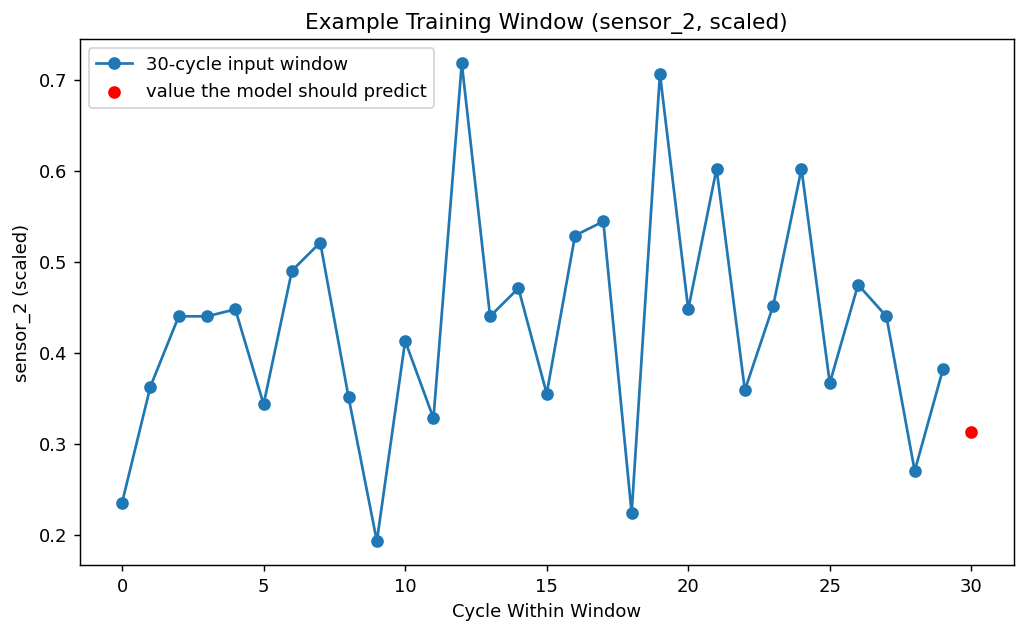

In [6]:
example_sensor = keep_sensors[0]
sensor_index = keep_sensors.index(example_sensor)

example_X = X_train[0, :, sensor_index]
example_y = y_train[0, sensor_index]

plt.figure(figsize=(8, 5))
plt.plot(range(WINDOW), example_X, marker="o", label="30-cycle input window")
plt.scatter([WINDOW], [example_y], color="red", zorder=5, label="value the model should predict")
plt.title(f"Example Training Window ({example_sensor}, scaled)")
plt.xlabel("Cycle Within Window")
plt.ylabel(f"{example_sensor} (scaled)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/9.emmy_example_window.png", dpi=130, bbox_inches="tight")
plt.show()


**Takeaway:** the window is just the sensor's recent history, and the target is simply the very next
reading — exactly what we want the TCN to learn to predict.


## 6. Building and training the TCN

Everything above has already been run and the numbers/plot are real. **The cells from here on need
TensorFlow**, which isn't available in the shared environment used to write this notebook — but it's
already listed in `requirements.txt`, so it will run fine in your own project `.venv`.

**To get real results below:** open this notebook with the `.venv` kernel selected, and use
**Run All**. Everything above will re-run instantly (it's cheap); the cells below will actually train
the model, which takes a few minutes on a laptop CPU.

### Why this section looks different from the rest of the notebook

Everything above this point is pandas/NumPy/scikit-learn — the same kind of code as `emmy_analysis.ipynb`.
From here on, we're no longer using a ready-made model like `LogisticRegression()` or
`RandomForestClassifier()`, where the library builds the whole thing for you in one line. A TCN
isn't a stock model in any library — it's a specific architecture (from research papers on
time-series models) that we have to assemble ourselves, layer by layer, using Keras's **Functional
API**. That's a different (and more manual) way of building a model than the simpler `Sequential`
API you may have seen before — it's needed here because a TCN has branches (the residual
connections below) that a plain stack of layers can't express.

**In short: the code below is genuinely more advanced than the rest of the notebook. That's expected
— it's inherent to what a TCN is, not a sign that anything here is over-complicated.** We won't be
walking through this code in the presentation itself (we'll talk about what the *results* — the plots
and numbers — tell us, not the implementation), but the comments below are here so you can explain any
piece of it yourself if a teammate or examiner asks.

### What a TCN actually does, in plain terms

A TCN looks at the last 30 cycles and tries to guess the next reading, the same way you might guess
tomorrow's temperature from the last month's weather. It does this using 1D convolutions — small
sliding filters that scan across time — stacked with increasing gaps between the points they look at
("dilation"), so the network can consider both very recent cycles and cycles further back at the same
time. Critically, it's **causal**: at any point it only ever looks backwards, never at future cycles
(that would be cheating).


### 🔧 Advanced code ahead: `build_tcn()`

This is the single most advanced cell in the notebook. Plain-language guide to what each part is doing
(matching the numbered comments in the code):

1. **Input** — declares the shape of one training example: 30 cycles × 14 sensors.
2. **The loop over `dilations`** — builds four stacked "blocks". Each block is one dilation rate
   (1, 2, 4, 8), so together they let the network see patterns at four different time-scales at once
   without needing a huge, slow filter.
3. **`Conv1D(..., padding="causal", dilation_rate=...)`** — the actual sliding filter for this block.
   `padding="causal"` is what enforces "never look at the future". `dilation_rate` controls the gap
   between the points the filter reads (rate 8 means it reads every 8th cycle, spanning further back
   in time using the same-size filter).
4. **The residual connection (`x = layers.Add()([x, residual])`)** — adds each block's *input* back
   onto its *output*. This is borrowed from ResNet-style networks and exists purely to make training
   more stable — without it, stacking several blocks tends to make training harder, not better.
5. **The `if residual.shape[-1] != filters:` line** — a small technical fix so step 4 works: the
   residual and the block's output need the same number of channels to be added together, so if they
   don't match we pass the residual through a 1×1 convolution first, purely to resize it (no time
   mixing happens here, unlike step 3).
6. **The `Lambda` layer** — after the last block, we have a prediction "in progress" for every one of
   the 30 timesteps, but we only care about predicting what comes *right after* cycle 30. This line
   just throws away everything except that last timestep.
7. **`Dense(n_features)`** — a plain fully-connected output layer that turns the network's internal
   representation into one predicted value per sensor.


In [ ]:
from tensorflow import keras  # type: ignore
from tensorflow.keras import layers  # type: ignore


def build_tcn(window, n_features, filters=32, kernel_size=3, dilations=(1, 2, 4, 8)):
    """A small TCN: stacked causal, dilated 1D convolutions with residual connections."""
    # 1. Input: one example = a (30 cycles, 14 sensors) block.
    inputs = keras.Input(shape=(window, n_features))
    x = inputs

    # 2. One "block" per dilation rate — this is what stacks up the TCN's ability to see
    #    both recent and distant history at once.
    for dilation_rate in dilations:
        residual = x  # keep a copy of this block's input, needed for step 4/5 below

        # 3. ADVANCED: the causal, dilated convolution — the core building block of a TCN.
        #    padding="causal" = only ever look backwards in time (never at future cycles).
        #    dilation_rate = how far apart the points this filter reads are spaced out.
        x = layers.Conv1D(
            filters=filters, kernel_size=kernel_size, padding="causal",
            dilation_rate=dilation_rate, activation="relu",
        )(x)
        x = layers.Dropout(0.1)(x)  # randomly zero out 10% of values during training, to reduce overfitting

        # 5. ADVANCED (technical fix, not conceptually important): make sure `residual` has the
        #    same number of channels as `x` so step 4's addition below is possible.
        if residual.shape[-1] != filters:
            # match the number of channels so the residual can be added back in
            residual = layers.Conv1D(filters=filters, kernel_size=1, padding="same")(residual)

        # 4. ADVANCED: the residual ("skip") connection — add the block's input back onto its
        #    output. Borrowed from ResNet; makes deeper stacks of these blocks train more reliably.
        x = layers.Add()([x, residual])

    # 6. ADVANCED: we only need the network's understanding of "right now" (the last timestep)
    #    to predict what comes next, so we throw away the other 29 timesteps here.
    last_step = layers.Lambda(lambda t: t[:, -1, :])(x)

    # 7. Standard output layer: one predicted value per sensor.
    outputs = layers.Dense(n_features)(last_step)

    return keras.Model(inputs, outputs, name="emmy_tcn")


n_features = len(keep_sensors)
model = build_tcn(window=WINDOW, n_features=n_features)
model.compile(optimizer="adam", loss="mse")  # "mse" = penalize the model more for being more wrong
model.summary()


### Training

We hold back 10% of the healthy windows as validation data, purely to watch for overfitting — the
model never trains on those. `EarlyStopping` stops training once validation loss stops improving, and
restores the best-performing version of the model automatically. Nothing below is TCN-specific — this
is the same standard training setup you'd use for pretty much any Keras model.


In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",      # watch the validation loss (error on data the model didn't train on)
    patience=5,               # stop if it hasn't improved for 5 epochs in a row
    restore_best_weights=True,  # roll back to the best-performing epoch, not just the last one
)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,   # hold back 10% of X_train/y_train, unseen during weight updates
    epochs=50,               # upper limit — EarlyStopping will likely stop it sooner
    batch_size=64,           # how many examples the model looks at before each weight update
    callbacks=[early_stopping],
    verbose=1,
)


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("TCN Training Progress")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/10.emmy_tcn_training_loss.png", dpi=130, bbox_inches="tight")
plt.show()


**What to look for:** both lines should drop quickly at first and then flatten out. If validation loss
starts climbing while training loss keeps falling, that's overfitting — `EarlyStopping` should catch it
automatically and roll back to the best epoch.


## 7. Turning prediction error into a warning signal

Now for the actual point of this model: run it across an engine's **entire** life (healthy *and*
degrading), and measure how wrong its predictions are at each cycle. Since the model only ever learned
what *healthy* behaviour looks like, its error should stay low early on and climb as the engine starts
behaving differently from what its own history would predict.


This function reuses `make_windows()` from section 4 — same idea as building the training data, but
now we run it across an engine's *whole* life (not just the healthy part) and feed every window into
the trained model with `model.predict()`, purely to compare its guess against what actually happened
next. Not TCN-specific — this pattern (slide a trained model across new data, measure the error) works
the same way for any next-step-prediction model, including an Autoencoder's reconstruction error.


In [ ]:
def compute_error_signal(engine_df, model, window=WINDOW):
    """Slide the trained TCN across one engine's full life and return (cycles, prediction_error)."""
    engine_df = engine_df.sort_values("time_in_cycles")
    arr = engine_df[keep_sensors].values
    X, y_true = make_windows(arr, window)  # same windowing function as training, just on full-life data
    if len(X) == 0:
        return np.array([]), np.array([])
    y_pred = model.predict(X, verbose=0)  # the model's guess for each window
    error = np.mean((y_true - y_pred) ** 2, axis=1)  # how wrong it was, averaged over all 14 sensors
    cycles = engine_df["time_in_cycles"].values[window:]  # cycle number each error value corresponds to
    return cycles, error


In [ ]:
example_units = [
    cycles_per_engine.idxmin(),
    cycles_per_engine.index[(cycles_per_engine - cycles_per_engine.median()).abs().argsort().iloc[0]],
    cycles_per_engine.idxmax(),
]
labels = ["shortest-lived", "typical", "longest-lived"]

plt.figure(figsize=(8, 5))
for unit, label in zip(example_units, labels):
    engine_df = train[train["unit_number"] == unit]
    cycles, error = compute_error_signal(engine_df, model)
    plt.plot(cycles, error, label=f"Engine {unit} ({label}, {cycles_per_engine[unit]} cycles)")

plt.axvspan(0, 0.30 * cycles_per_engine[example_units[1]], alpha=0.1,
            label="approx. healthy period (typical engine)")
plt.title("TCN Prediction Error Over an Engine's Life")
plt.xlabel("Cycle")
plt.ylabel("Prediction Error (MSE)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/11.emmy_tcn_prediction_error.png", dpi=130, bbox_inches="tight")
plt.show()


**What to look for:** the error should stay low and flat during the healthy period, then trend upward
as each engine approaches failure. That rising trend *is* the warning signal.


## 8. Does the warning signal actually track true Remaining Useful Life?

Here's the real test, using the group's agreed evaluation method: for every test engine, we compute
the TCN's prediction error at its cutoff cycle (the last cycle we're allowed to see), and check how
strongly that error relates to the *true* Remaining Useful Life given in `RUL_FD001.txt` — which the
model never saw during training.

A good warning signal should be **high when RUL is low** (engine close to failure) and **low when RUL
is high** (engine still healthy) — in other words, a strong *negative* correlation.


In [ ]:
final_errors = []
for unit in test["unit_number"].unique():
    engine_df = test[test["unit_number"] == unit]
    cycles, error = compute_error_signal(engine_df, model)
    # use the error at the last available cycle - that's "right now" for this test engine
    final_errors.append(error[-1] if len(error) > 0 else np.nan)

results = pd.DataFrame({
    "unit_number": test["unit_number"].unique(),
    "final_error": final_errors,
    "true_RUL": rul_test["RUL"].values,
})

correlation = results["final_error"].corr(results["true_RUL"])
print(f"Correlation between TCN warning signal and true RUL: {correlation:.3f}")
print("(closer to -1 is better: high error should mean low remaining life)")

plt.figure(figsize=(8, 5))
plt.scatter(results["true_RUL"], results["final_error"], alpha=0.6)
plt.title("TCN Warning Signal vs. True Remaining Useful Life")
plt.xlabel("True Remaining Useful Life (cycles)")
plt.ylabel("TCN Prediction Error at Cutoff")
plt.tight_layout()
plt.savefig("../reports/figures/12.emmy_tcn_warning_vs_rul.png", dpi=130, bbox_inches="tight")
plt.show()


## 9. How early does the warning actually trigger?

The second evaluation the group agreed on: **how many cycles before failure** does the warning signal
first cross a threshold? We use the healthy-period error itself to set a sensible threshold (mean +
2 standard deviations of a "normal" error), then check, for every *training* engine (which we watch
all the way to failure), how many cycles of advance warning the TCN would have given.


In [ ]:
# Build the threshold from healthy-period errors across all training engines.
# "mean + 2 std" is a common rule of thumb for "clearly outside normal range" (covers ~95% of
# normal healthy-period error values, so anything above it is a genuine outlier, not just noise).
healthy_errors = []
for unit in train["unit_number"].unique():
    engine_df = train[train["unit_number"] == unit]
    cycles, error = compute_error_signal(engine_df, model)
    is_healthy_cycle = cycles <= 0.30 * cycles_per_engine[unit]
    healthy_errors.append(error[is_healthy_cycle])

healthy_errors = np.concatenate(healthy_errors)
threshold = healthy_errors.mean() + 2 * healthy_errors.std()
print(f"Warning threshold (healthy mean + 2 std): {threshold:.5f}")

# For every engine, find the FIRST cycle where the error crosses the threshold, and measure
# how many cycles that was before the engine actually failed.
warning_times = []
for unit in train["unit_number"].unique():
    engine_df = train[train["unit_number"] == unit]
    cycles, error = compute_error_signal(engine_df, model)
    above_threshold = np.where(error > threshold)[0]  # indices where the error is "too high"
    if len(above_threshold) > 0:
        first_warning_cycle = cycles[above_threshold[0]]  # first time it crossed the line
        early_warning = cycles_per_engine[unit] - first_warning_cycle  # how early that was
        warning_times.append(early_warning)

warning_times = np.array(warning_times)
print(f"Engines that triggered a warning before failure: {len(warning_times)} / {len(cycles_per_engine)}")
print(f"Average early-warning time: {warning_times.mean():.1f} cycles")

plt.figure(figsize=(8, 5))
plt.hist(warning_times, bins=20)
plt.title("How Many Cycles Before Failure the TCN First Warned")
plt.xlabel("Early-Warning Time (cycles before failure)")
plt.ylabel("Number of Engines")
plt.tight_layout()
plt.savefig("../reports/figures/13.emmy_tcn_early_warning_time.png", dpi=130, bbox_inches="tight")
plt.show()


## Summary

This notebook builds a TCN that predicts each engine's next sensor reading from its last 30 cycles of
healthy behaviour, then uses how wrong those predictions get as an early-warning signal for
degradation.

Once you've run it locally with TensorFlow, you should have:

1. A trained TCN, with a training/validation loss curve to sanity-check it actually learned something.
2. A prediction-error signal per engine that should visibly rise as engines approach failure.
3. A correlation number between the TCN's warning signal and true Remaining Useful Life on the test
   set — the headline number for comparing against the Autoencoder later.
4. An early-warning-time distribution — how many cycles of advance notice the TCN tends to give.

Points 3 and 4 are exactly the two comparison metrics the group agreed on, so once Mahtab's Autoencoder
notebook produces the same two numbers, they can go side by side in the final comparison.
